In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm as tqdm
from statannotations.Annotator import Annotator

In [2]:
df_timming = pd.read_csv('./timing_mrc5/UT_timing_smooth_300000.bedGraph', sep='\t', header=None)
# # # df_early = pd.read_csv('/mnt/data/kaustav/Hi-c/Cut_and_Run/H3K9me3_CutnRun_repli-CutnRun/raw_data_20241101/sriram_data/seacr_peaks_normalized_by_NORM_function_seacr/', sep='\t', header=None)
# # # df_late = pd.read_csv('/mnt/data/kaustav/Hi-c/Cut_and_Run/H3K9me3_CutnRun_repli-CutnRun/raw_data_20241101/sriram_data/seacr_peaks_normalized_by_NORM_function_seacr/RPE_late.bedGraph', sep='\t', header=None)
# # # print(len(df_early))
# # # print(len(df_late))
# # # df_timming = pd.merge(df_early, df_late, how='inner', on=[0, 1, 2])
# # # df_timming[4] = df_timming['3_x'] - df_timming['3_y']
# # # df_timming = df_timming.drop(['3_x', '3_y'], axis=1)
# # # df_timming = df_timming[df_timming[3]!=0]
# # df_timming
# # df_timming = pd.read_csv('../timing_mrc5/', sep='\t', header=None)
# df_early = pd.read_csv('./timing_mrc5/Early_UT_sorted.bedGraph', sep='\t', header=None)
# df_late = pd.read_csv('./timing_mrc5/Late_UT_sorted.bedGraph', sep='\t', header=None)
# print(len(df_early))
# print(len(df_late))
# df_timming = pd.merge(df_early, df_late, how='inner', on=[0, 1, 2])
# df_timming[4] = df_timming['3_x'] - df_timming['3_y']
# df_timming = df_timming.drop(['3_x', '3_y'], axis=1)
df_timming[4] = df_timming[3]
df_timming

,0,1,2,3,4
0,chr1,0,16250,3.138725,3.138725
1,chr1,16250,16300,2.967999,2.967999
2,chr1,16300,16350,2.967486,2.967486
3,chr1,16350,16400,2.966974,2.966974
4,chr1,16400,16450,2.966461,2.966461
...,...,...,...,...,...
28822983,ML143385.1,5850,5950,-3.424482,-3.424482
28822984,ML143385.1,5950,6000,-3.340563,-3.340563
28822985,ML143385.1,6000,13750,-3.299377,-3.299377
28822986,ML143385.1,13750,13800,-3.262194,-3.262194


In [50]:
df_tad = pd.read_csv('./bigwig_files/2023-11-04-Rep-HiC-HU_rerun.merged_sort.MAPQ.30.10k.TADs_domains.bed',
            sep='\t', header=None)
df_tad['length'] = abs(df_tad[2] - df_tad[1])
df_tad

,0,1,2,3,4,5,6,7,8,length
0,chr1,1120000,1300000,ID_0.01_1,0.422793,.,1120000,1300000,"31,120,180",180000
1,chr1,1300000,1520000,ID_0.01_2,-0.098146,.,1300000,1520000,"51,160,44",220000
2,chr1,1520000,1780000,ID_0.01_3,0.036241,.,1520000,1780000,"31,120,180",260000
3,chr1,1780000,1930000,ID_0.01_4,-0.007631,.,1780000,1930000,"51,160,44",150000
4,chr1,1930000,2120000,ID_0.01_5,-0.214866,.,1930000,2120000,"31,120,180",190000
...,...,...,...,...,...,...,...,...,...,...
7571,chrY,13270000,16490000,ID_0.01_7572,-0.143640,.,13270000,16490000,"51,160,44",3220000
7572,chrY,16490000,16540000,ID_0.01_7573,0.007511,.,16490000,16540000,"31,120,180",50000
7573,chrY,16540000,16860000,ID_0.01_7574,0.011383,.,16540000,16860000,"51,160,44",320000
7574,chrY,16860000,17080000,ID_0.01_7575,0.009928,.,16860000,17080000,"31,120,180",220000


In [51]:
# df_timming.to_csv('./RPE_rt.bedGraph', sep='\t', header=None, index=None)
df_timming[4] = df_timming[3]
df_timming

,0,1,2,3,4
0,chr1,0,16250,3.138725,3.138725
1,chr1,16250,16300,2.967999,2.967999
2,chr1,16300,16350,2.967486,2.967486
3,chr1,16350,16400,2.966974,2.966974
4,chr1,16400,16450,2.966461,2.966461
...,...,...,...,...,...
28822983,ML143385.1,5850,5950,-3.424482,-3.424482
28822984,ML143385.1,5950,6000,-3.340563,-3.340563
28822985,ML143385.1,6000,13750,-3.299377,-3.299377
28822986,ML143385.1,13750,13800,-3.262194,-3.262194


In [52]:
import numpy as np
import pandas as pd
from tqdm import tqdm

def percent_early_late_fast(df_tad, df_timming, value_col=3):
    """
    For each TAD (chr, start, end, length), compute:
      - % of timing bins fully inside with value > 0  -> 'early'
      - % of timing bins fully inside with value < 0  -> 'late'
    Uses searchsorted + prefix sums. Expects:
      df_tad:   cols 0(chrom),1(start),2(end), and optionally 'length'
      df_timming: cols 0(chrom),1(start),2(end), value_col (e.g., 4)
    Returns DataFrame: ['chr','start','end','early','late','length']
    """

    # sort for cache-friendly grouping
    tad = df_tad.sort_values([0,1,2], kind="mergesort").reset_index(drop=True)
    tim = df_timming.sort_values([0,1,2], kind="mergesort").reset_index(drop=True)

    out = []

    for chrom, tad_chr in tqdm(tad.groupby(0), desc="Chromosomes"):
        tim_chr = tim[tim[0] == chrom]
        T = len(tad_chr)

        # defaults: NaN when a TAD contains no timing bins
        early_pct = np.full(T, np.nan, dtype=float)
        late_pct  = np.full(T, np.nan, dtype=float)

        if not tim_chr.empty:
            # timing bins (must be sorted by start & end as read)
            b_start = tim_chr[1].to_numpy()
            b_end   = tim_chr[2].to_numpy()
            vals    = tim_chr[value_col].to_numpy()

            # prefix sums of class indicators
            pos = (vals > 0).astype(np.int64)
            neg = (vals < 0).astype(np.int64)

            pos_ps = np.zeros(pos.size + 1, dtype=np.int64)
            neg_ps = np.zeros(neg.size + 1, dtype=np.int64)
            pos_ps[1:] = np.cumsum(pos)
            neg_ps[1:] = np.cumsum(neg)

            # TAD starts/ends
            ts = tad_chr[1].to_numpy()
            te = tad_chr[2].to_numpy()

            # For each TAD, bins fully inside satisfy:
            #   b_start >= ts  AND  b_end <= te
            # Since arrays are monotonic, the satisfied indices are contiguous:
            #   L = first idx with b_start >= ts
            #   R = last  idx with b_end   <= te  = searchsorted(b_end, te, 'right') - 1
            L = np.searchsorted(b_start, ts, side="left")
            R = np.searchsorted(b_end,   te, side="right") - 1

            valid = R >= L
            n_inside = np.zeros(T, dtype=np.int64)
            pos_cnt  = np.zeros(T, dtype=np.int64)
            neg_cnt  = np.zeros(T, dtype=np.int64)

            if valid.any():
                idxL = L[valid]
                idxR = R[valid]
                # counts via prefix sums
                n_inside[valid] = (idxR - idxL + 1)
                pos_cnt[valid]  = pos_ps[idxR + 1] - pos_ps[idxL]
                neg_cnt[valid]  = neg_ps[idxR + 1] - neg_ps[idxL]

                # percentages
                nz = n_inside > 0
                early_pct[nz] = pos_cnt[nz] / n_inside[nz] * 100.0
                late_pct[nz]  = neg_cnt[nz] / n_inside[nz] * 100.0

        out.append(pd.DataFrame({
            "chr":   tad_chr[0].to_numpy(),
            "start": tad_chr[1].to_numpy(),
            "end":   tad_chr[2].to_numpy(),
            "early": early_pct,
            "late":  late_pct,
            "length": (tad_chr["length"].to_numpy()
                       if "length" in tad_chr.columns
                       else (tad_chr[2] - tad_chr[1]).to_numpy())
        }))

    return pd.concat(out, ignore_index=True)

# ---- run ----
# df_per will match your original output schema but computed fast
df_per = percent_early_late_fast(df_tad, df_timming, value_col=4)

# (optional) splits like before
per = 80
df_per_early = df_per[df_per["early"] >= per]
df_per_late  = df_per[df_per["late"]  >= per]
df_per_mid   = df_per[(df_per["early"] < per) & (df_per["late"] < per)]

print(len(df_per_early))
print(len(df_per_late))
print(len(df_per_mid))

Chromosomes: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:23<00:00,  1.04it/s]

4656
2107
793


In [53]:
# per = 80
# df_per = pd.DataFrame(persentage, columns=['chr', 'start', 'end', 'early', 'late', 'length'])
# print(len(df_per[df_per['early'] >= per]))
# df_per_early = df_per[df_per['early'] >= per]
# print(len(df_per[df_per['late'] >= per]))
# df_per_late = df_per[df_per['late'] >= per]
# print(len(df_per) - len(df_per[df_per['early'] >= per]) - len(df_per[df_per['late'] >= per]))
# df_per_mid = df_per[(df_per['early'] < per) & (df_per['late'] < per)]

In [54]:
df_per

,chr,start,end,early,late,length
0,chr1,1120000,1300000,100.000000,0.000000,180000
1,chr1,1300000,1520000,100.000000,0.000000,220000
2,chr1,1520000,1780000,100.000000,0.000000,260000
3,chr1,1780000,1930000,100.000000,0.000000,150000
4,chr1,1930000,2120000,100.000000,0.000000,190000
...,...,...,...,...,...,...
7571,chrY,13270000,16490000,0.000000,100.000000,3220000
7572,chrY,16490000,16540000,0.000000,100.000000,50000
7573,chrY,16540000,16860000,0.000000,100.000000,320000
7574,chrY,16860000,17080000,0.000000,100.000000,220000


In [55]:
df_loop = pd.read_csv('./loops/2023-11-04-Rep-HiC-UT_rerun.merged_loops.bedpe',
            sep='\t', header=None)
df_loop[2] = df_loop[5]
df_loop

,0,1,2,3,4,5
0,chr1,890000,980000,chr1,970000,980000
1,chr1,1310000,1620000,chr1,1610000,1620000
2,chr1,1940000,2040000,chr1,2030000,2040000
3,chr1,2175000,2400000,chr1,2375000,2400000
4,chr1,2410000,2550000,chr1,2540000,2550000
...,...,...,...,...,...,...
12649,chrY,15340000,15460000,chrY,15450000,15460000
12650,chrY,15400000,15470000,chrY,15460000,15470000
12651,chrY,16510000,16580000,chrY,16570000,16580000
12652,chrY,17130000,17380000,chrY,17370000,17380000


In [56]:
covorage = []
i = 1
for index, row in tqdm(df_per.iterrows(), total=len(df_per)):
    count1 = len( df_loop[
        (df_loop[0] == row[0]) & 
        (df_loop[1] >= (row[1] - 10000) ) &  
        (df_loop[2] <= (row[2] + 10000) )])
    count2 = len( df_loop[
        (df_loop[0] == row[0]) & 
        (df_loop[1] <= (row[1] - 10000) ) &  
        (df_loop[2] >= (row[1] + 10000) )])
    count3 = len( df_loop[
        (df_loop[0] == row[0]) & 
        (df_loop[1] <= (row[2] - 10000) ) &  
        (df_loop[2] >= (row[2] + 10000) )])
    
    covorage.append([row[0], row[1], row[2], (count1 + count2 + count3)])
df_covorage_all = pd.DataFrame(covorage, columns=['chr', 'start', 'end', 'loop_dencity'])
df_covorage_all = df_covorage_all[df_covorage_all['loop_dencity'] > 0]
df_covorage_all['type'] = 'all'

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7576/7576 [00:17<00:00, 431.64it/s]


In [57]:
covorage = []
i = 1
for index, row in tqdm(df_per_early.iterrows(), total=len(df_per_early)):
    count1 = len( df_loop[
        (df_loop[0] == row[0]) & 
        (df_loop[1] >= (row[1] - 10000) ) &  
        (df_loop[2] <= (row[2] + 10000) )])
    count2 = len( df_loop[
        (df_loop[0] == row[0]) & 
        (df_loop[1] <= (row[1] - 10000) ) &  
        (df_loop[2] >= (row[1] + 10000) )])
    count3 = len( df_loop[
        (df_loop[0] == row[0]) & 
        (df_loop[1] <= (row[2] - 10000) ) &  
        (df_loop[2] >= (row[2] + 10000) )])
    
    covorage.append([row[0], row[1], row[2], (count1 + count2 + count3)])
df_early_covorage = pd.DataFrame(covorage, columns=['chr', 'start', 'end', 'loop_dencity'])
df_early_covorage = df_early_covorage[df_early_covorage['loop_dencity'] > 0]
df_early_covorage['type'] = 'early'

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4656/4656 [00:10<00:00, 432.65it/s]


In [58]:
covorage = []
i = 1
for index, row in tqdm(df_per_late.iterrows(), total=len(df_per_late)):
    count1 = len( df_loop[
        (df_loop[0] == row[0]) & 
        (df_loop[1] >= (row[1] - 10000) ) &  
        (df_loop[2] <= (row[2] + 10000) )])
    count2 = len( df_loop[
        (df_loop[0] == row[0]) & 
        (df_loop[1] <= (row[1] - 10000) ) &  
        (df_loop[2] >= (row[1] + 10000) )])
    count3 = len( df_loop[
        (df_loop[0] == row[0]) & 
        (df_loop[1] <= (row[2] - 10000) ) &  
        (df_loop[2] >= (row[2] + 10000) )])
    
    covorage.append([row[0], row[1], row[2], (count1 + count2 + count3)])
df_late_covorage = pd.DataFrame(covorage, columns=['chr', 'start', 'end', 'loop_dencity'])
df_late_covorage = df_late_covorage[df_late_covorage['loop_dencity'] > 0]
df_late_covorage['type'] = 'late'

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2107/2107 [00:04<00:00, 431.37it/s]


In [59]:
covorage = []
i = 1
for index, row in tqdm(df_per_mid.iterrows(), total=len(df_per_mid)):
    count1 = len( df_loop[
        (df_loop[0] == row[0]) & 
        (df_loop[1] >= (row[1] - 10000) ) &  
        (df_loop[2] <= (row[2] + 10000) )])
    count2 = len( df_loop[
        (df_loop[0] == row[0]) & 
        (df_loop[1] <= (row[1] - 10000) ) &  
        (df_loop[2] >= (row[1] + 10000) )])
    count3 = len( df_loop[
        (df_loop[0] == row[0]) & 
        (df_loop[1] <= (row[2] - 10000) ) &  
        (df_loop[2] >= (row[2] + 10000) )])
    
    covorage.append([row[0], row[1], row[2], (count1 + count2 + count3)])
df_mid_covorage = pd.DataFrame(covorage, columns=['chr', 'start', 'end', 'loop_dencity'])
df_mid_covorage = df_mid_covorage[df_mid_covorage['loop_dencity'] > 0]
df_mid_covorage['type'] = 'mid'
# df_mid_covorage

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 793/793 [00:01<00:00, 434.54it/s]


/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_11338/2728416959.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=combined_df, x='type', y='loop_dencity', palette='Set2')


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

all vs. early: t-test independent samples, P_val:1.668e-16 t=8.256e+00
early vs. late: t-test independent samples, P_val:3.952e-57 t=-1.609e+01
all vs. late: t-test independent samples, P_val:4.843e-25 t=-1.037e+01


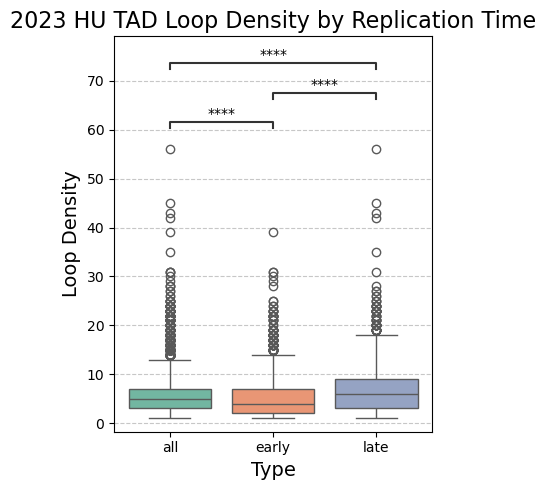

In [60]:
# Combine the DataFrames
# Combine the DataFrames
combined_df = pd.concat([df_covorage_all, df_early_covorage, df_late_covorage], ignore_index=True)
# combined_df = combined_df[combined_df['loop_dencity'] <= 30]

# Define the box pairs for comparison
box_pairs = [("early", "all"), ("all", "late"), ("early", "late")]

# Create the boxplot
plt.figure(figsize=(4, 5))
ax = sns.boxplot(data=combined_df, x='type', y='loop_dencity', palette='Set2')

# Initialize the Annotator
annotator = Annotator(ax, pairs=box_pairs, data=combined_df, x='type', y='loop_dencity')

# Add annotations using a statistical test
annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()

# Customize the plot
plt.title("2023 HU TAD Loop Density by Replication Time", fontsize=16)
plt.xlabel("Type", fontsize=14)
plt.ylabel("Loop Density", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.savefig('./fig_1/2023_Tad_loop_dencity_HU_all_new.svg', dpi=1200, format='svg')
plt.show()

In [164]:
combined_df['length'] = combined_df['end'] - combined_df['start']
combined_df

,chr,start,end,loop_dencity,type,length
0,chr1,1300000,1520000,1,all,220000
1,chr1,1520000,1780000,1,all,260000
2,chr1,1930000,2120000,1,all,190000
3,chr1,2120000,2390000,2,all,270000
4,chr1,2390000,2720000,6,all,330000
...,...,...,...,...,...,...
12259,chrX,150740000,151110000,2,late,370000
12260,chrX,154885000,155100000,1,late,215000
12261,chrY,7510000,7890000,2,late,380000
12262,chrY,11720000,13270000,2,late,1550000


<Axes: xlabel='length', ylabel='Count'>

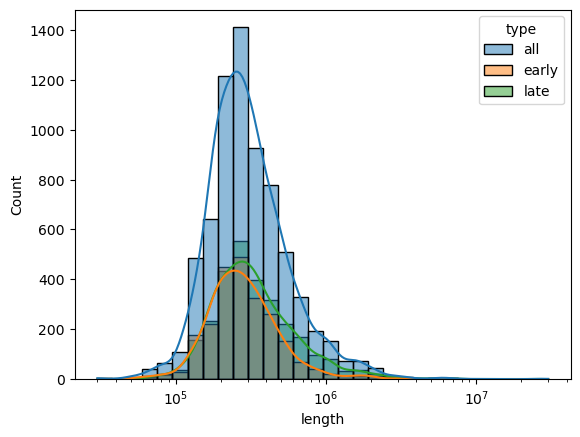

In [165]:
sns.histplot(data=combined_df, x="length", hue="type", bins=30, log_scale=True, kde=True)

<Axes: xlabel='length', ylabel='Count'>

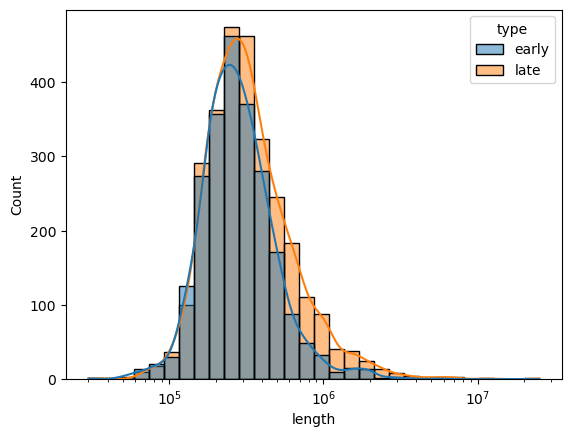

In [166]:
df_filtered = combined_df[combined_df["type"] != "all"]
sns.histplot(data=df_filtered, x="length", hue="type", bins=30, log_scale=True, kde=True)